**bold text**
## Github Repository Link
https://github.com/imparwasha/AI-Assignments

In [1]:
# important libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")
data.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131,complete,7/1/2016,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,\N,...,7,2016-7,7-2016,FY17,1,NaN,NaN,NaN,NaN,NaN
1,211133,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,\N,...,7,2016-7,7-2016,FY17,2,NaN,NaN,NaN,NaN,NaN
2,211134,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,\N,...,7,2016-7,7-2016,FY17,3,NaN,NaN,NaN,NaN,NaN
3,211135,complete,7/1/2016,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7,2016-7,7-2016,FY17,4,NaN,NaN,NaN,NaN,NaN
4,211136,order_refunded,7/1/2016,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,\N,...,7,2016-7,7-2016,FY17,5,NaN,NaN,NaN,NaN,NaN


In [3]:
# Remove unused columns

data.drop(['Customer ID'], axis=1, inplace=True, errors='Ignore')

In [4]:
# check null values.

data.isnull().sum()

,0
item_id,0
status,0
created_at,0
sku,5
price,0
qty_ordered,0
grand_total,0
increment_id,0
category_name_1,0
sales_commission_code,0


In [5]:
# fill with mean

data.fillna(data.mean(numeric_only=True), inplace=True)

In [6]:
# handle duplicates

data.drop_duplicates(inplace=True)

In [7]:
# handle categorical features

data = pd.get_dummies(data, drop_first=True, sparse=True)

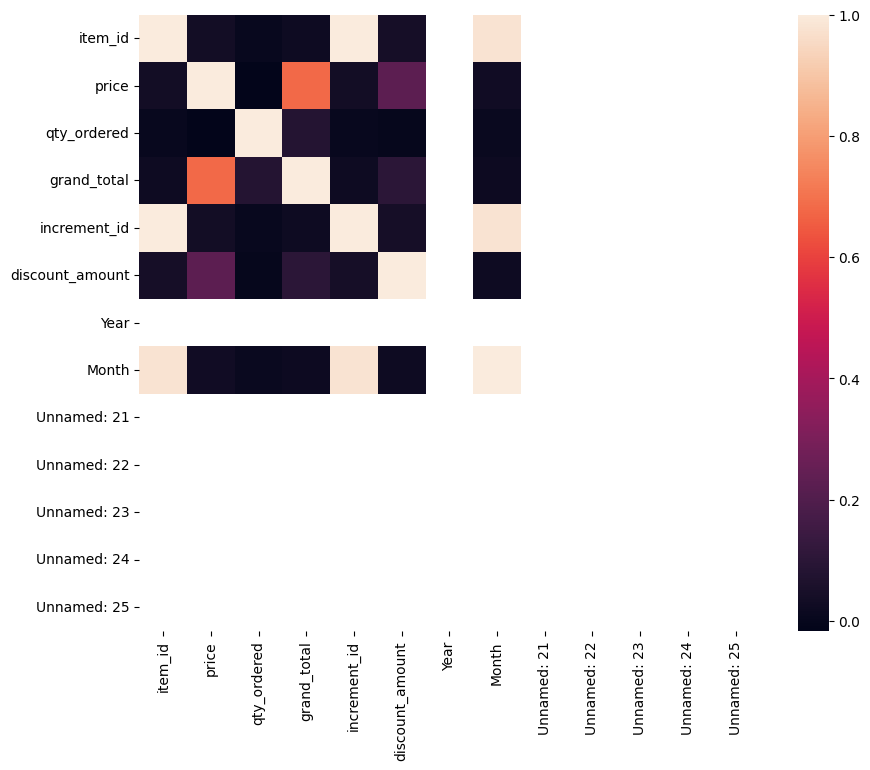

In [8]:
# correlation

corr = data.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()

In [9]:
data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")

/tmp/ipykernel_375/2051359929.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Pakistan Largest Ecommerce Dataset.csv")


In [10]:
# correlation with target variable
data['grand_total'] = pd.to_numeric(data['grand_total'], errors='coerce')
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols].corr()['grand_total'].sort_values(ascending=False)

,grand_total
grand_total,1.000000
qty_ordered,0.905914
price,0.151361
discount_amount,0.040059
Year,0.014102
item_id,0.008362
Customer ID,0.006949
Month,-0.015971
Unnamed: 21,NaN
Unnamed: 22,NaN


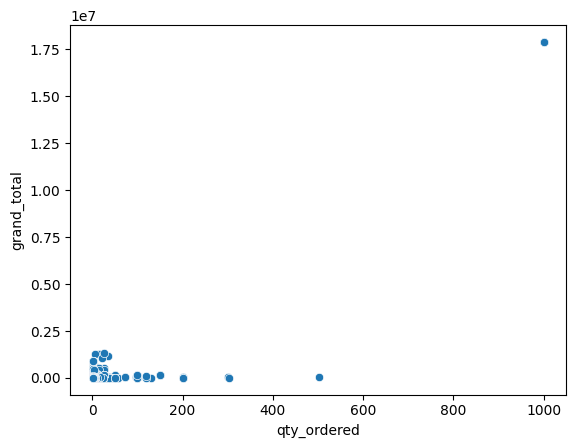

In [11]:
#scatter plot

sns.scatterplot(x='qty_ordered', y='grand_total', data=data)
plt.show()

In [12]:
# handle outliers

Q1 = data['grand_total'].quantile(0.25)
Q3 = data['grand_total'].quantile(0.75)
IQR = Q3 - Q1
data = data[(data['grand_total'] >= Q1 - 1.5 * IQR) & (data['grand_total'] <= Q3 + 1.5 * IQR)]



In [13]:
# data analytics
# best selling category

data['category_name_1'].value_counts()

,count
category_name_1,
Men's Fashion,49000
Mobiles & Tablets,29495
Superstore,27109
Women's Fashion,26129
Soghaat,25877
Beauty & Grooming,21995
Appliances,12782
Home & Living,11357
Kids & Baby,9239


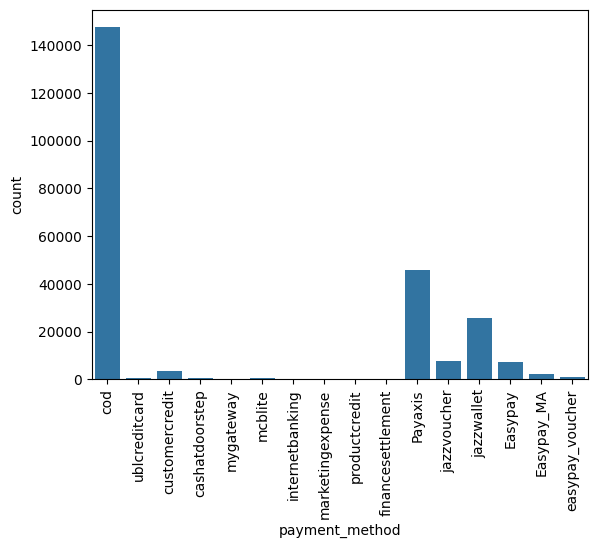

In [14]:
# payment method frequency

sns.countplot(x='payment_method', data=data)
plt.xticks(rotation=90)
plt.show()

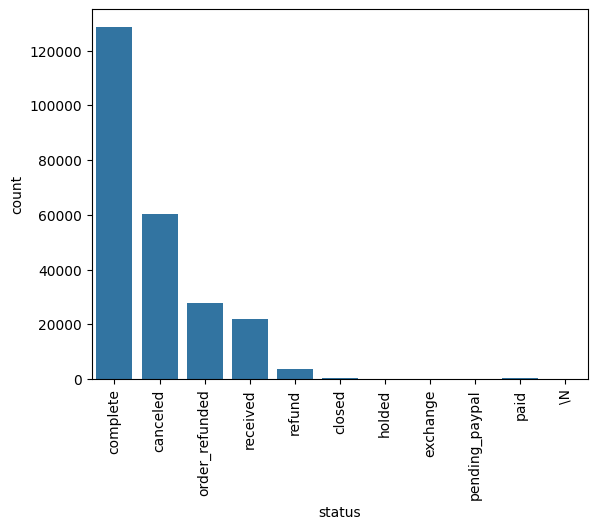

In [15]:
# order status frequency

sns.countplot(x='status', data=data)
plt.xticks(rotation=90)
plt.show()

In [16]:
# correlation payment method & order status

pd.crosstab(data['payment_method'], data['status'])

status,\N,canceled,closed,complete,exchange,holded,order_refunded,paid,pending_paypal,received,refund
payment_method,,,,,,,,,,,
Easypay,0,5055,0,1353,0,0,297,27,0,416,19
Easypay_MA,0,1228,0,544,0,0,84,5,0,210,6
Payaxis,0,28730,18,11194,0,0,1644,173,0,3993,221
cashatdoorstep,0,4,0,632,0,0,28,0,0,0,17
cod,4,8571,235,96353,4,6,24287,0,3,15069,2984
customercredit,0,26,11,2652,0,0,557,0,0,287,141
easypay_voucher,0,575,0,177,0,0,95,0,0,40,8
financesettlement,0,0,0,0,0,0,1,0,0,0,0
internetbanking,0,191,4,118,0,0,11,0,0,0,6


In [17]:
# correlation payment method & order status

pd.crosstab(data['payment_method'], data['status'])

status,\N,canceled,closed,complete,exchange,holded,order_refunded,paid,pending_paypal,received,refund
payment_method,,,,,,,,,,,
Easypay,0,5055,0,1353,0,0,297,27,0,416,19
Easypay_MA,0,1228,0,544,0,0,84,5,0,210,6
Payaxis,0,28730,18,11194,0,0,1644,173,0,3993,221
cashatdoorstep,0,4,0,632,0,0,28,0,0,0,17
cod,4,8571,235,96353,4,6,24287,0,3,15069,2984
customercredit,0,26,11,2652,0,0,557,0,0,287,141
easypay_voucher,0,575,0,177,0,0,95,0,0,40,8
financesettlement,0,0,0,0,0,0,1,0,0,0,0
internetbanking,0,191,4,118,0,0,11,0,0,0,6


In [20]:
# save preprocessed dataset

data.to_csv('preprocessed_ecommerce_data.csv', index=False)